# **Klasifikasi Jenis Produk | Decision Tree**

Model klasifikasi jenis produk pada platform marketplace berdasarkan karakteristik menggunakan algoritma Decision Tree. 

## 1. Data Understanding

### 1.1 Import the Libraries

In [65]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import tkinter as tk
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tkinter import messagebox
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/akyrr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/akyrr/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/akyrr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### 1.2 Read the Dataset

In [66]:
# Import the datastet 
product = pd.read_csv('pricerunner_aggregate.csv')

# Show the top 5 of dataset 
print('\ntop 5 of the dataset:')
product.head()


top 5 of the dataset:


,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [67]:
# Show the information of dataset
print('\n Information of dataset:')
product.info()


 Information of dataset:
<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Product ID       35311 non-null  int64
 1   Product Title    35311 non-null  str  
 2    Merchant ID     35311 non-null  int64
 3    Cluster ID      35311 non-null  int64
 4    Cluster Label   35311 non-null  str  
 5    Category ID     35311 non-null  int64
 6    Category Label  35311 non-null  str  
dtypes: int64(4), str(3)
memory usage: 1.9 MB


In [68]:
# Show the dimensional of dataset 
print('\nNumber of rows:', product.shape[0])
print('Number of columns:', product.shape[1])


Number of rows: 35311
Number of columns: 7


In [69]:
# Show the number of unique vaues per columns
print('\nNumber of unique valus:')
product.nunique()


Number of unique valus:


Product ID         35311
Product Title      30993
 Merchant ID         306
 Cluster ID        13233
 Cluster Label     12849
 Category ID          10
 Category Label       10
dtype: int64

In [70]:
product = product.drop('Product ID', axis=1)
product.columns

Index(['Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label',
       ' Category ID', ' Category Label'],
      dtype='str')

In [71]:
# Show the number of missing values and duplicated data
print('\nNumber of missing value:', product.isnull().sum().sum())
print('Number of duplicated data:', product.duplicated().sum())


Number of missing value: 0
Number of duplicated data: 0


In [72]:
# Separate the numerical and categorical columns 
num_cols = product.select_dtypes(include=['int64', 'float64'])
cat_cols = product.select_dtypes(include=['category', 'object'])

print(num_cols.columns)
print(cat_cols.columns)

Index([' Merchant ID', ' Cluster ID', ' Category ID'], dtype='str')
Index(['Product Title', ' Cluster Label', ' Category Label'], dtype='str')


/tmp/ipykernel_40898/1736024674.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = product.select_dtypes(include=['category', 'object'])


In [73]:
# Show the unique values of the target 
print('Category Product:', product[' Category Label'].unique())

Category Product: <StringArray>
[   'Mobile Phones',              'TVs',             'CPUs',
  'Digital Cameras',       'Microwaves',      'Dishwashers',
 'Washing Machines',         'Freezers',  'Fridge Freezers',
          'Fridges']
Length: 10, dtype: str


In [74]:
# Show the 10 rows of category id and category label
col = [' Category ID', ' Category Label']
product[col].sample(10)

,Category ID,Category Label
13457,2617,Digital Cameras
6280,2614,TVs
24365,2621,Freezers
1132,2612,Mobile Phones
3394,2612,Mobile Phones
31311,2622,Fridge Freezers
22312,2620,Washing Machines
20175,2620,Washing Machines
9818,2615,CPUs
16323,2618,Microwaves


In [75]:
# Show the 20 rows of category id and category label
col = [' Cluster ID', ' Cluster Label']
product[col].sample(20)

,Cluster ID,Cluster Label
29839,44819,Hotpoint SXBHE925WD Black
31778,46117,Bosch KIR24V20GB Integrated
19069,41131,Bosch SPI25CW03E White
10556,6956,Intel Xeon E5-2630 v2 2.60GHz Box
23522,42709,Hoover HDB 854DN/1
24129,43274,Neff G4655X7GB Integrated
14636,39701,Panasonic NN-CF778SBPQ Stainless Steel
20538,41914,Indesit BWE 91484X W
4510,4445,LG 49UK6300PLB
32472,46220,Smeg FAB10RUJ Union Jack Retro


## 2. Exploratory Data Analysis

### 2.1 Multivariate Analysis

#### Statistical Analysis

In [76]:
# Show the statistical summary of dataset 
print('\nShow the statistical summary of numerical features')
num_cols.describe()


Show the statistical summary of numerical features


,Merchant ID,Cluster ID,Category ID
count,35311.000000,35311.000000,35311.000000
mean,120.501883,30110.687633,2618.142930
std,117.045557,18410.265642,3.600708
min,1.000000,1.000000,2612.000000
25%,17.000000,6123.000000,2615.000000
50%,75.000000,40630.000000,2619.000000
75%,253.000000,44059.000000,2622.000000
max,371.000000,47525.000000,2623.000000


In [77]:
# Show the statistical summary of dataset 
print('\nShow the statistical summary of categorical features')
cat_cols.describe()


Show the statistical summary of categorical features


,Product Title,Cluster Label,Category Label
count,35311,35311,35311
unique,30993,12849,10
top,washing machine,Canon IXUS 185,Fridge Freezers
freq,90,27,5501


#### Distribution Analysis

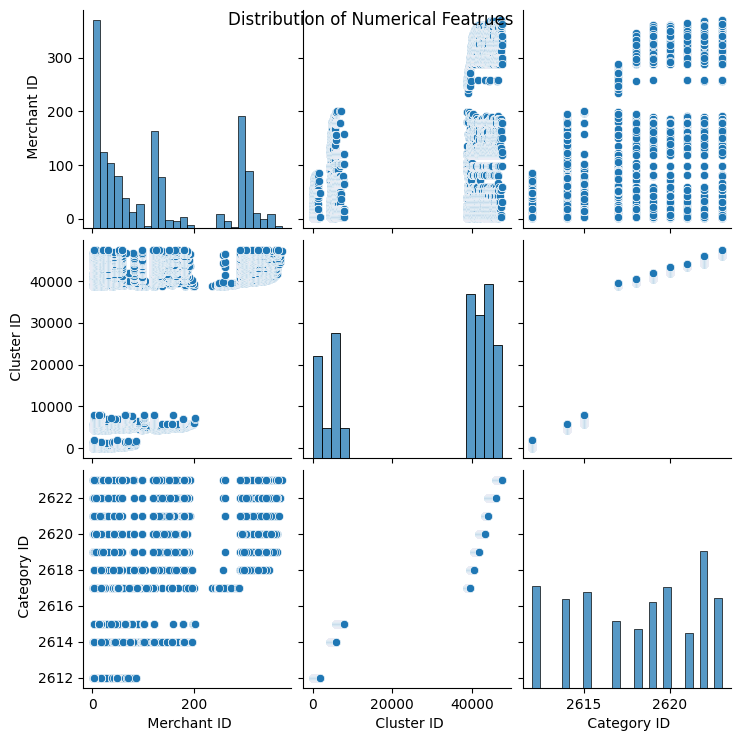

In [78]:
# Show the distribution of numerical featres
sns.pairplot(num_cols)
plt.suptitle('Distribution of Numerical Featrues')
plt.show()

#### Range Value Distribution Analysis

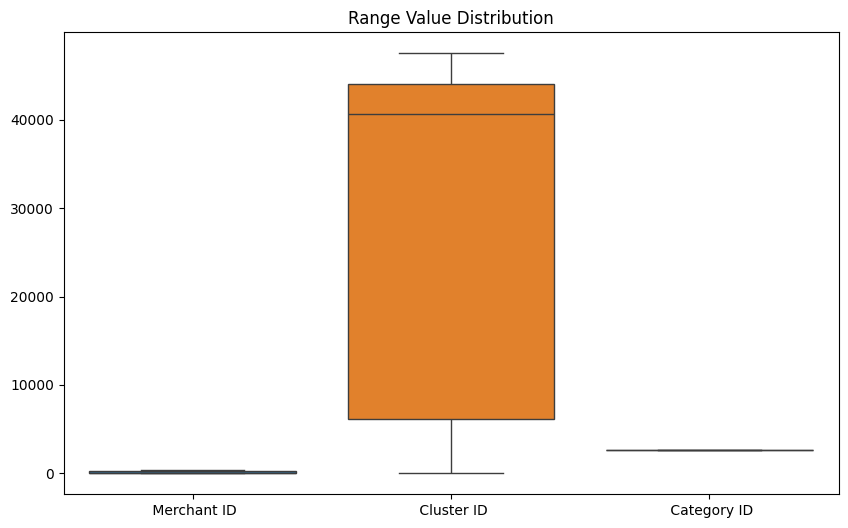

In [79]:
plt.figure(figsize=(10, 6))
sns.boxplot(num_cols)
plt.title('Range Value Distribution')
plt.show()

#### Correlation Analysis

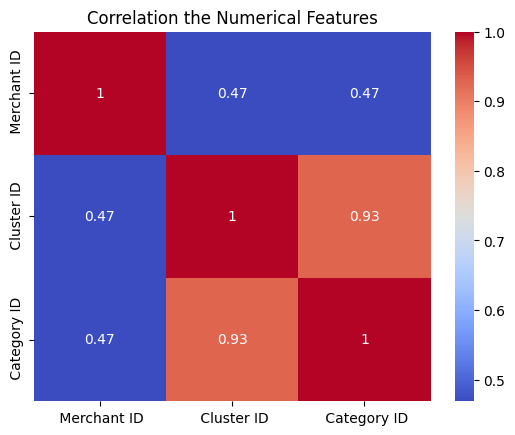

In [80]:
correlation = num_cols.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation the Numerical Features')
plt.show()

### 2.2 Univariate Analysis

#### Distribution of the Target

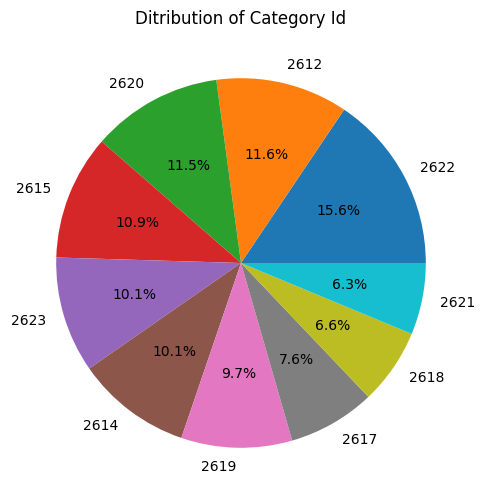

In [81]:
# Show the distribution of the target
plt.figure(figsize=(8,6))
plt.pie(product[' Category ID'].value_counts(), autopct='%1.1f%%', labels=product[' Category ID'].value_counts().index)
plt.title('Ditribution of Category Id')
plt.show()

/tmp/ipykernel_40898/578281834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=product, y=' Category Label', order=order, palette='viridis')


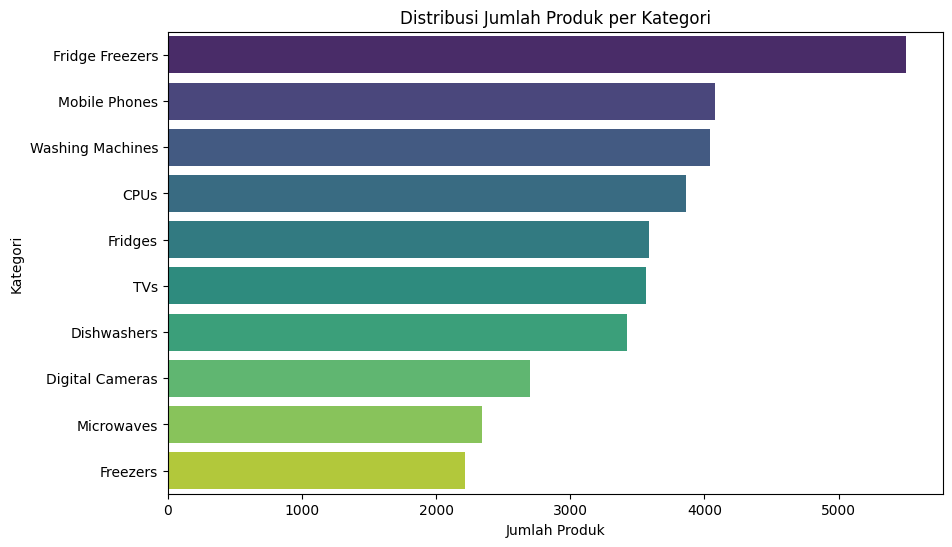

In [82]:
plt.figure(figsize=(10, 6))
order = product[' Category Label'].value_counts().index
sns.countplot(data=product, y=' Category Label', order=order, palette='viridis')
plt.title('Distribusi Jumlah Produk per Kategori')
plt.xlabel('Jumlah Produk')
plt.ylabel('Kategori')
plt.show()

#### Distribution of the Features

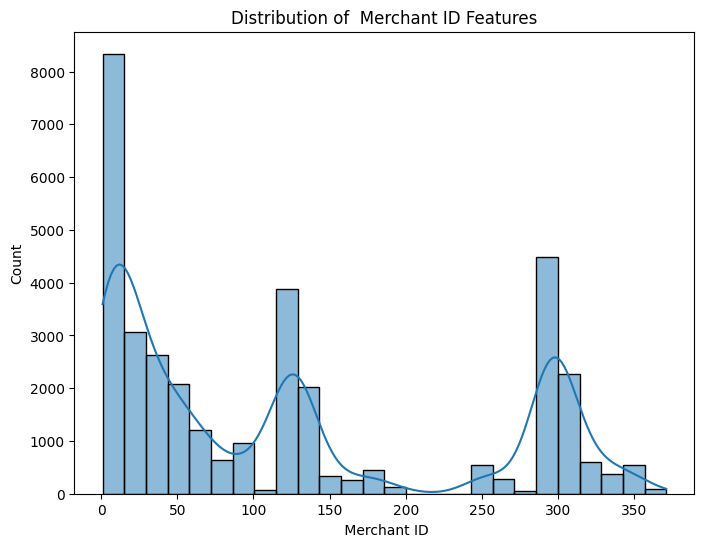

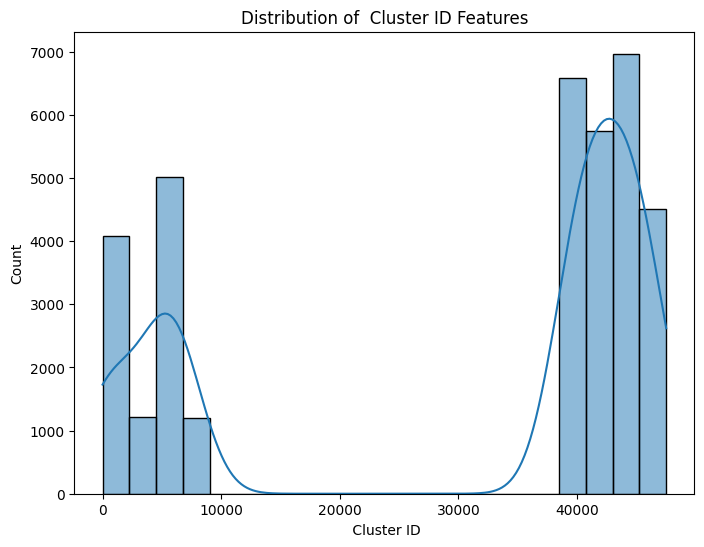

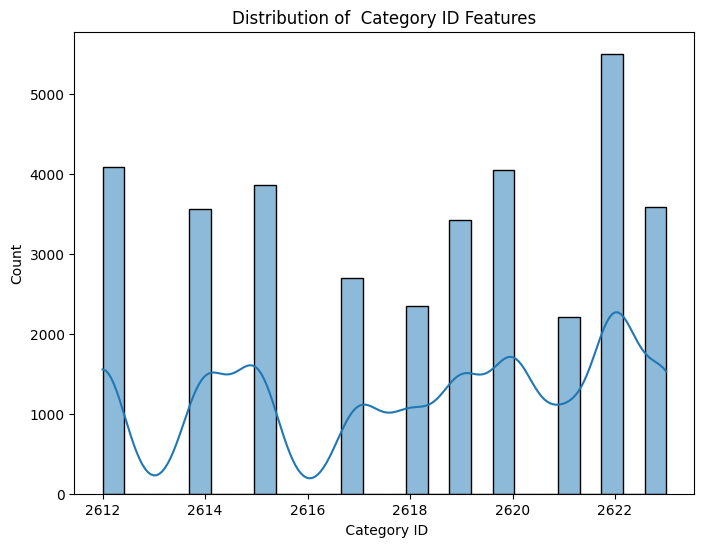

In [83]:
# Show the visualization of distribution numerical features
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(product[col], kde=True)
    plt.title(f'Distribution of {col} Features')
    plt.show()

In [84]:
for col in num_cols:
    print(f'\nDistribution of {col} Features:', product[col].value_counts())


Distribution of  Merchant ID Features:  Merchant ID
3      2547
6      1591
298    1523
31     1350
119    1239
       ... 
362       1
365       1
367       1
370       1
371       1
Name: count, Length: 306, dtype: int64

Distribution of  Cluster ID Features:  Cluster ID
38848    27
4419     24
38849    24
1        23
4420     23
         ..
47517     1
47518     1
47519     1
47524     1
47525     1
Name: count, Length: 13233, dtype: int64

Distribution of  Category ID Features:  Category ID
2622    5501
2612    4081
2620    4044
2615    3862
2623    3584
2614    3564
2619    3424
2617    2697
2618    2342
2621    2212
Name: count, dtype: int64


In [85]:
cat_cols.columns

Index(['Product Title', ' Cluster Label', ' Category Label'], dtype='str')

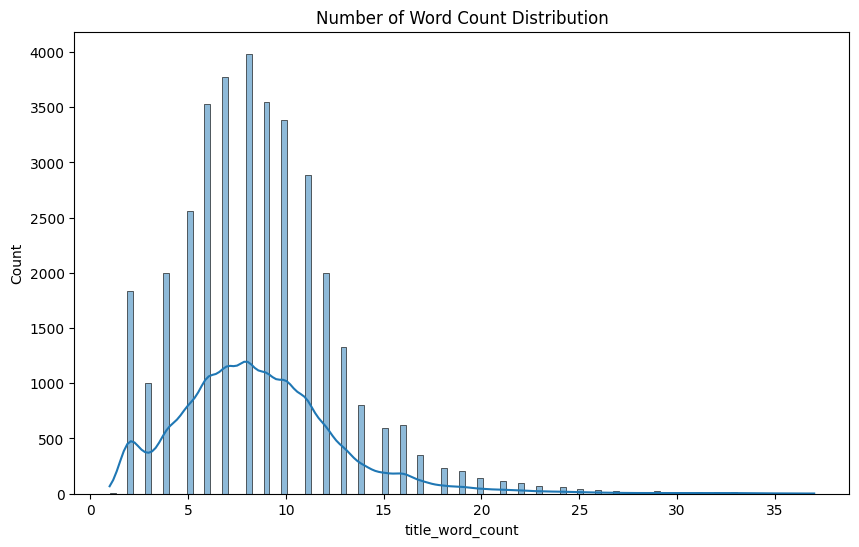

In [86]:
# show the visualization of categorical featrues
product['title_word_count'] = product['Product Title'].str.split().str.len()

plt.figure(figsize=(10, 6))
sns.histplot(data=product, x='title_word_count', kde=True)
plt.title('Number of Word Count Distribution')
plt.show()

In [87]:
duplicate_products = product.duplicated(subset=['Product Title']).sum()
print(f"\nAda {duplicate_products} judul produk yang muncul lebih dari satu kali.")


Ada 4318 judul produk yang muncul lebih dari satu kali.


In [88]:

product[' Cluster Label'] = product[' Cluster Label'].str.strip()
label_to_id_check = product.groupby(' Cluster Label')[' Cluster ID'].nunique()
label_bermasalah = label_to_id_check[label_to_id_check > 1]

print("Daftar Label yang memiliki lebih dari satu ID:")
print(label_bermasalah)

Daftar Label yang memiliki lebih dari satu ID:
 Cluster Label
AMD A8-7650K 3.3GHz  Box                                2
AMD FX-6350 3.9GHz  Box                                 2
AMD Opteron 2216 HE 2.4GHz Socket F 1000MHz bus Tray    2
AMD Opteron 2218 2.6GHz Socket F 1000MHz bus Tray       2
AMD Phenom II X4 945 3.0GHz Socket AM3 Box              2
                                                       ..
Miele G 4940 SCI                                        2
Siemens FI24DP02 Integrated                             2
Swan SM22090COPN Brown                                  2
Swan SR11050BLN Blue                                    2
Xiaomi Mi A1 32GB Dual SIM                              2
Name:  Cluster ID, Length: 176, dtype: int64


### 2.3 Bivariate Analysis

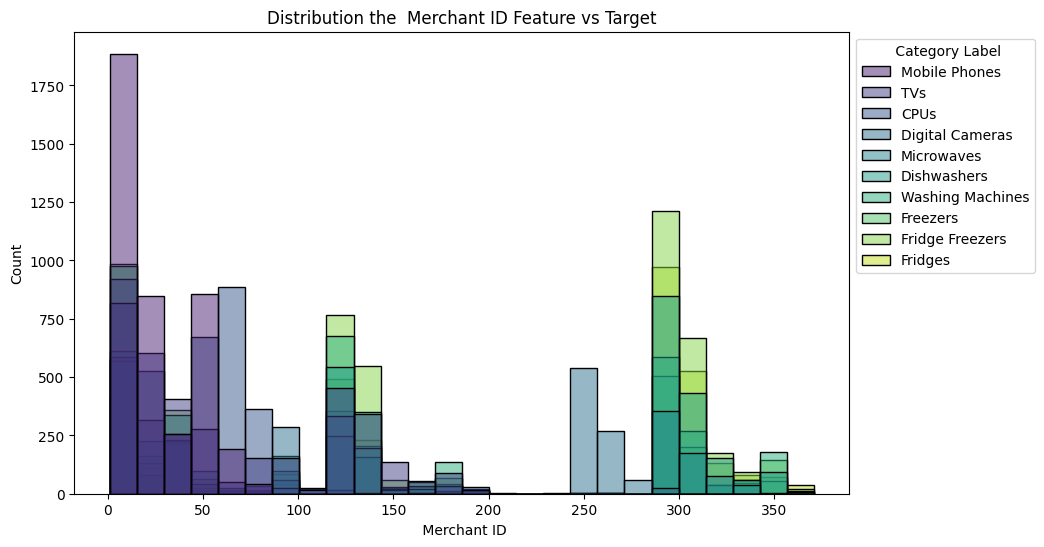

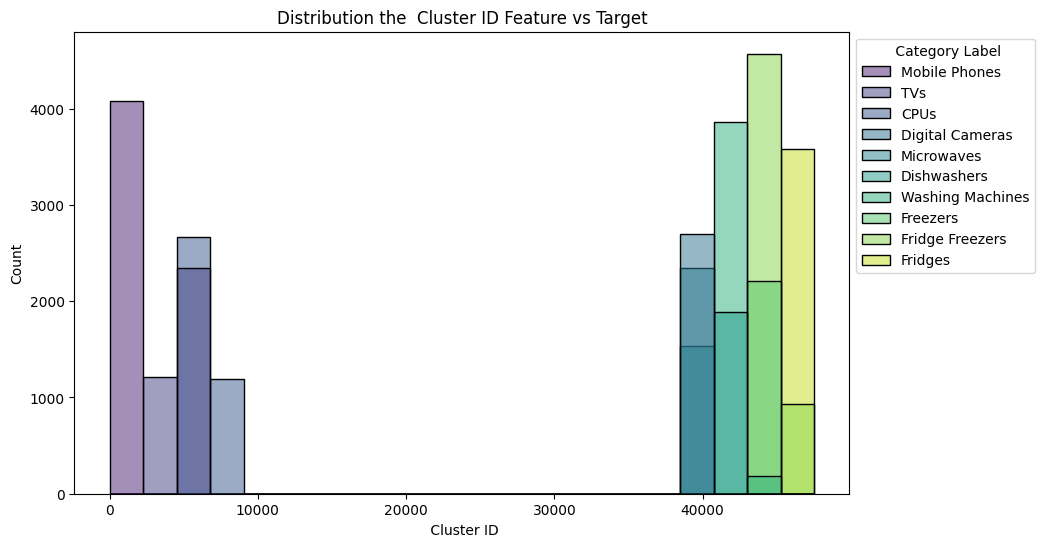

In [89]:
for col in num_cols:
    if col == ' Category ID':
        continue
    
    plt.figure(figsize=[10, 6])
    ax = sns.histplot(data=product, x=col, hue=' Category Label', palette='viridis')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))
    plt.title(f'Distribution the {col} Feature vs Target')
    plt.show()

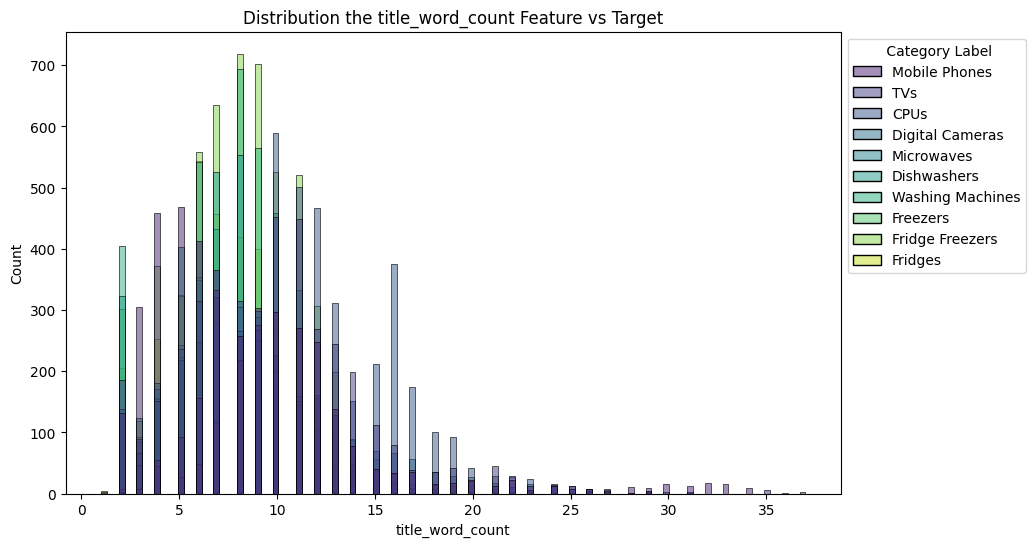

In [90]:
plt.figure(figsize=[10, 6])
ax = sns.histplot(data=product, x='title_word_count', hue=' Category Label', palette='viridis')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))
plt.title(f'Distribution the {'title_word_count'} Feature vs Target')
plt.show()

## 3. Data Preprocessing

### 3.1 Text Cleaning

#### Data Cleaning

In [91]:
product.columns = product.columns.str.strip()

In [92]:
product['Product Title'].nunique()

30993

In [93]:
def nltk_cleaner(text):
    if not isinstance(text, str): return ""
    
    # 1. Case Normalization
    text = text.lower()

    # 2. Noise Removal (Hanya biarkan huruf, angka, dan spasi)
    allowed = "abcdefghijklmnopqrstuvwxyz0123456789 "
    text = "".join([char for char in text if char in allowed])

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Stopwords Removal (English)
    stop_words = set(stopwords.words('english'))
    
    custom_stops = {'ready', 'grosir', 'stock', 'shipping', 'free', 'new'}
    stop_words.update(custom_stops)
    
    clean_tokens = [w for w in tokens if w not in stop_words]
    
    return " ".join(clean_tokens)

product['Clean_Title'] = product['Product Title'].apply(nltk_cleaner)

In [94]:
product['Clean_Title'].sample(10)

26638               blomberg knm4561i built fridge freezer
29796    haier hrf 522ig6 american style fridge freezer...
10554       intel xeon e5 2680v2 processor 28 ghz 25 mb l3
22085    hotpoint wmxtf842p 8kg 1400 spin washing machi...
25940    indesit ui41w1 uk white 142cm tall 194 litre f...
27972    hotpoint hmcb7030aa 177cm integrated 7030 frid...
3386                                            htc one a9
13567                           canon eos 800d starter kit
12606          panasonic lumix dc ft7 digital camera black
18888       zanussi zdt24001fa fully integrated dishwasher
Name: Clean_Title, dtype: str

In [95]:
product['Clean_Title'].nunique()

30925

In [96]:
product.head()

,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label,title_word_count,Clean_Title
0,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,6,apple iphone 8 plus 64gb silver
1,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,7,apple iphone 8 plus 64 gb spacegrau
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,13,apple mq8n2ba iphone 8 plus 64gb 55 12mp sim s...
3,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,7,apple iphone 8 plus 64gb space grey
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,11,apple iphone 8 plus gold 55 64gb 4g unlocked sim


### 3.2 Encoding Target 

In [97]:
category_mapping = {
    'Mobile Phones': 0,
    'TVs': 1,
    'CPUs': 2,
    'Digital Cameras': 3,
    'Microwaves': 4,
    'Dishwashers': 5,
    'Washing Machines': 6,
    'Freezers': 7,
    'Fridge Freezers': 8,
    'Fridges': 9
}

product['target'] = product['Category Label'].str.strip().map(category_mapping)
id_to_category = {v: k for k, v in category_mapping.items()}
print(id_to_category)

{0: 'Mobile Phones', 1: 'TVs', 2: 'CPUs', 3: 'Digital Cameras', 4: 'Microwaves', 5: 'Dishwashers', 6: 'Washing Machines', 7: 'Freezers', 8: 'Fridge Freezers', 9: 'Fridges'}


### 3.3 TF-IDF

In [98]:
# Show the distribution of target
product['target'].value_counts()

target
8    5501
0    4081
6    4044
2    3862
9    3584
1    3564
5    3424
3    2697
4    2342
7    2212
Name: count, dtype: int64

In [99]:
def hitung_tf(kalimat):
    kata_kata = kalimat.split()
    if not kata_kata:
        return {}
    
    # Hitung kemunculan tiap kata
    counts = {}
    for kata in kata_kata:
        counts[kata] = counts.get(kata, 0) + 1
    
    # Cari angka kemunculan tertinggi (max fd)
    max_fd = 0
    for kata in counts:
        if counts[kata] > max_fd:
            max_fd = counts[kata]
            
    # Hitung TF = count / max_fd
    tf_hasil = {}
    for kata in counts:
        tf_hasil[kata] = counts[kata] / max_fd
        
    return tf_hasil

In [100]:
def hitung_idf(semua_kalimat):
    total_dokumen = len(semua_kalimat)
    kemunculan_kata_di_dokumen = {}
    
    # Hitung di berapa dokumen kata itu muncul
    for kalimat in semua_kalimat:
        kata_unik = set(kalimat.split())
        for kata in kata_unik:
            kemunculan_kata_di_dokumen[kata] = kemunculan_kata_di_dokumen.get(kata, 0) + 1
            
    idf_hasil = {}
    for kata, jumlah in kemunculan_kata_di_dokumen.items():
        # Pengganti Log: Rasio sederhana (Total / (Jumlah + 1))
        # Semakin jarang kata muncul, nilainya semakin besar
        idf_hasil[kata] = total_dokumen / (jumlah + 1)
        
    return idf_hasil

In [240]:
product_shuffled = product.sample(frac=1, random_state=42).reset_index(drop=True)

data_sampel = product_shuffled['Clean_Title'].head(5000).tolist()
y = product_shuffled['target'].head(5000).values

# 1. Hitung IDF 
skor_idf = hitung_idf(data_sampel)

# 2. Hitung TF-IDF per baris
hasil_tfidf_lengkap = []

for kalimat in data_sampel:
    skor_tf = hitung_tf(kalimat)
    tfidf_per_kalimat = {}
    
    for kata, nilai_tf in skor_tf.items():
        # TF * IDF
        tfidf_per_kalimat[kata] = nilai_tf * skor_idf.get(kata, 0)
    
    hasil_tfidf_lengkap.append(tfidf_per_kalimat)

for i, hasil in enumerate(hasil_tfidf_lengkap):
    print(f"Produk {i+1}: {hasil}")
X_tfidf = pd.DataFrame(hasil_tfidf_lengkap).fillna(0)
X_tfidf = X_tfidf.fillna(0)
print("Matriks Independent (X) hasil TF-IDF:")
print(X_tfidf)

Produk 1: {'bosch': 11.061946902654867, 'serie': 40.0, '4': 27.3224043715847, 'kil22vf30g': 1666.6666666666667, 'integrated': 13.850415512465373, 'fridge': 5.5005500550055}
Produk 2: {'sony': 26.17801047120419, 'kd75xf8596bu': 1250.0, '75': 208.33333333333334, '4k': 21.27659574468085, 'hdr': 28.90173410404624, 'ultra': 26.595744680851062, 'hd': 17.857142857142858, 'smart': 15.384615384615385, 'android': 55.55555555555556, 'led': 19.9203187250996, 'tv': 12.72264631043257, 'amazon': 2500.0, 'alexa': 2500.0}
Produk 3: {'sony': 26.17801047120419, 'xperia': 156.25, 'xa2': 1000.0, 'ultra': 26.595744680851062, 'black': 9.041591320072333, '6': 45.04504504504504, '32gb': 98.03921568627452, '4g': 55.55555555555556, 'unlocked': 53.191489361702125, 'sim': 25.380710659898476}
Produk 4: {'pentax': 384.61538461538464, 'k': 26.595744680851062, '1': 87.71929824561404, 'body': 62.5, 'hd': 17.857142857142858, '24': 96.15384615384616, '70mm': 714.2857142857143, 'f2': 1666.6666666666667, '8': 42.3728813559

### 3.3 Independent & Dependent Variables

In [241]:
product.columns

Index(['Product Title', 'Merchant ID', 'Cluster ID', 'Cluster Label',
       'Category ID', 'Category Label', 'title_word_count', 'Clean_Title',
       'target'],
      dtype='str')

In [242]:
hasil_tfidf_lengkap

[{'bosch': 11.061946902654867,
  'serie': 40.0,
  '4': 27.3224043715847,
  'kil22vf30g': 1666.6666666666667,
  'integrated': 13.850415512465373,
  'fridge': 5.5005500550055},
 {'sony': 26.17801047120419,
  'kd75xf8596bu': 1250.0,
  '75': 208.33333333333334,
  '4k': 21.27659574468085,
  'hdr': 28.90173410404624,
  'ultra': 26.595744680851062,
  'hd': 17.857142857142858,
  'smart': 15.384615384615385,
  'android': 55.55555555555556,
  'led': 19.9203187250996,
  'tv': 12.72264631043257,
  'amazon': 2500.0,
  'alexa': 2500.0},
 {'sony': 26.17801047120419,
  'xperia': 156.25,
  'xa2': 1000.0,
  'ultra': 26.595744680851062,
  'black': 9.041591320072333,
  '6': 45.04504504504504,
  '32gb': 98.03921568627452,
  '4g': 55.55555555555556,
  'unlocked': 53.191489361702125,
  'sim': 25.380710659898476},
 {'pentax': 384.61538461538464,
  'k': 26.595744680851062,
  '1': 87.71929824561404,
  'body': 62.5,
  'hd': 17.857142857142858,
  '24': 96.15384615384616,
  '70mm': 714.2857142857143,
  'f2': 1666.

In [243]:
merchant_feature = product['Merchant ID'].head(len(hasil_tfidf_lengkap)).reset_index(drop=True)
X_final_df = pd.concat([merchant_feature, X_tfidf], axis=1)

# Independent and dependent variabels
X = X_final_df.values
y = product['target'].head(len(hasil_tfidf_lengkap)).values

print(f"Dimensional X: {X.shape}") 


Dimensional X: (5000, 6704)


## 4. Model 

In [244]:
def split_data(X, y, size=0.8):
    np.random.seed(42)
    train_idx, test_idx = [], []

    for i in np.unique(y):
        idx = np.where(y == i)[0]
        idx_permuted = np.random.permutation(idx)
        split_point = int(len(idx_permuted) * size)
        train_idx.extend(idx_permuted[:split_point])
        test_idx.extend(idx_permuted[split_point:])

    train_idx = np.array(train_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [245]:
X_train, X_test, y_train, y_test = split_data(X, y)
for val in [X_train, X_test, y_train, y_test]:
    print(val.shape)

(3999, 6704)
(1001, 6704)
(3999,)
(1001,)


In [246]:
y_train

array([0, 0, 0, ..., 1, 1, 1], shape=(3999,))

In [238]:
class Node:
    def __init__(self):
        self.pred_class = None
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.gini = None
        self.num_samples = None

class DTCART:
    def __init__(self, max_depth=3, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_split = min_samples_split
        self.min_leaf = min_samples_leaf
        self.root = None
        self.classes = None

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        self.classes = np.unique(y)
        self.root = self._grow(X, y, 0)
        return self
    
    def _gini(self, y):
        m = len(y)
        if m == 0: return 0
        probs = np.bincount(y, minlength=len(self.classes)) / m
        return 1 - np.sum(probs ** 2)
    
    def _split(self, X, y):
        m, n = X.shape
        if m < self.min_split: return None, None

        best_gini = self._gini(y) # Mulai dengan nilai tinggi
        best_feature, best_threshold = None, None

        for feature in range(n):
            idx = np.argsort(X[:, feature])
            x_sorted, y_sorted = X[idx, feature], y[idx]

            left_counts = np.zeros(len(self.classes), dtype=int)
            right_counts = np.bincount(y_sorted, minlength=len(self.classes))

            for i in range(1, m):
                c = y_sorted[i-1]
                left_counts[c] += 1
                right_counts[c] -= 1 # PERBAIKAN: Dikurangi, bukan ditambah

                if x_sorted[i] == x_sorted[i-1]:
                    continue

                if i < self.min_leaf or (m - i) < self.min_leaf:
                    continue

                # Hitung Gini secara manual untuk performa
                gini_left = 1 - np.sum((left_counts / i)**2)
                gini_right = 1 - np.sum((right_counts / (m - i))**2)
                
                # Weighted Gini Impurity
                weighted_gini = (i * gini_left + (m - i) * gini_right) / m

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = (x_sorted[i] + x_sorted[i-1]) / 2

        return best_feature, best_threshold

    def _grow(self, X, y, depth):
        if len(y) == 0: return None
        
        node = Node()
        node.num_samples = len(y)
        node.gini = self._gini(y)
        node.pred_class = np.bincount(y).argmax()

        if (self.max_depth and depth >= self.max_depth) or \
           len(y) < self.min_split or \
           len(np.unique(y)) == 1:
            return node

        feature, threshold = self._split(X, y)
        if feature is None: return node

        left_mask = X[:, feature] <= threshold
        node.feature = feature
        node.threshold = threshold
        
        node.left = self._grow(X[left_mask], y[left_mask], depth + 1)
        node.right = self._grow(X[~left_mask], y[~left_mask], depth + 1)
        return node
    
    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x) for x in X])

    def _predict_one(self, x):
        node = self.root
        # Telusuri sampai ke leaf
        while node.left is not None and node.right is not None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        
        if node is None:
            return self.classes[0]
        
        return self.classes[node.pred_class] if node else 0

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [247]:
best_acc = 0
best_depth = None
accuracy = []

for depth in [2,3,4,5,6,7,8,9,10,11]:
    model = DTCART(max_depth=depth)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = np.mean(y_test == pred)

    print(f'Depth: {depth} - Accuracy: {acc:.4f}')

    if acc > best_acc:
        best_acc = acc
        best_depth = depth
print(f'Best Depth: {best_depth} - Accuracy: {best_acc:.4f}')   

KeyboardInterrupt: 

In [249]:
model = DTCART(max_depth=9)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

## 5. Evaluation

In [154]:
def evaluate(y_true, y_pred, title='Train'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    for i in np.unique(y):
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        accuracy = np.mean(y_true == y_pred)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f'Evaluasi {title}')
    print(f'Accuracy    : {accuracy:.4f}')
    print(f'Precision   : {precision:.4f}')
    print(f'Recall      : {recall:.4f}')
    print(f'F1          : {f1:.4f}')

In [251]:
evaluate(y_train, y_pred_train)
evaluate(y_test, y_pred_test, title='Test')

Evaluasi Train
Accuracy    : 0.9445
Precision   : 0.9430
Recall      : 0.7429
F1          : 0.8311
Evaluasi Test
Accuracy    : 0.9221
Precision   : 0.8841
Recall      : 0.6630
F1          : 0.7578


## 6. Visualization 

In [ ]:
def cmtrx(y_true, y_pred, title='Train'):
    classes = np.unique(y_true)
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes))

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i,j] = np.sum((y_true == c_true) * (y_pred == c_pred))

    plt.figure(figsize=(10,8))
    plt.title(f'Confusion Matrix {title}', fontsize=15)
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', cbar=False, xticklabels=classes, yticklabels=classes)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

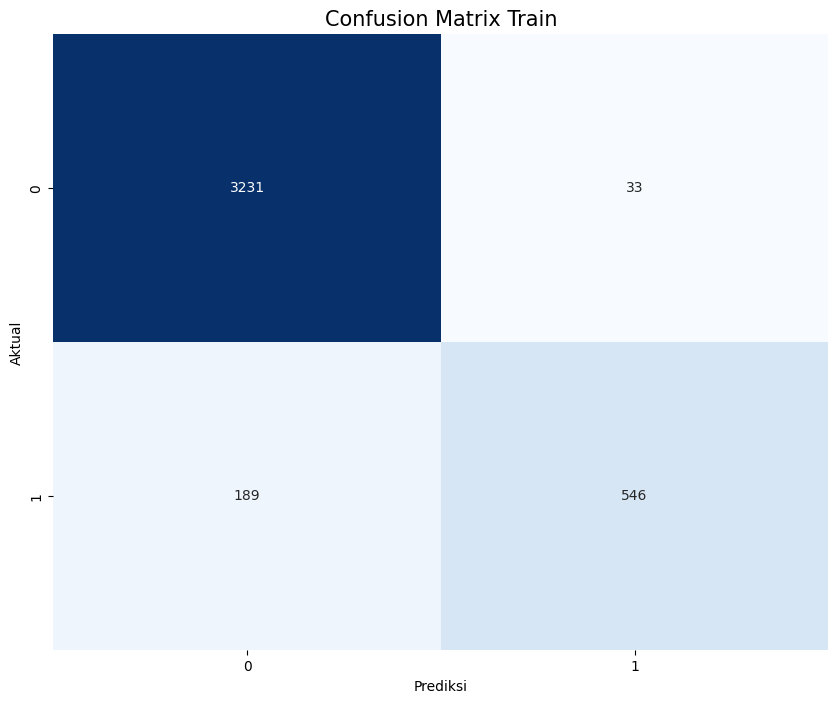

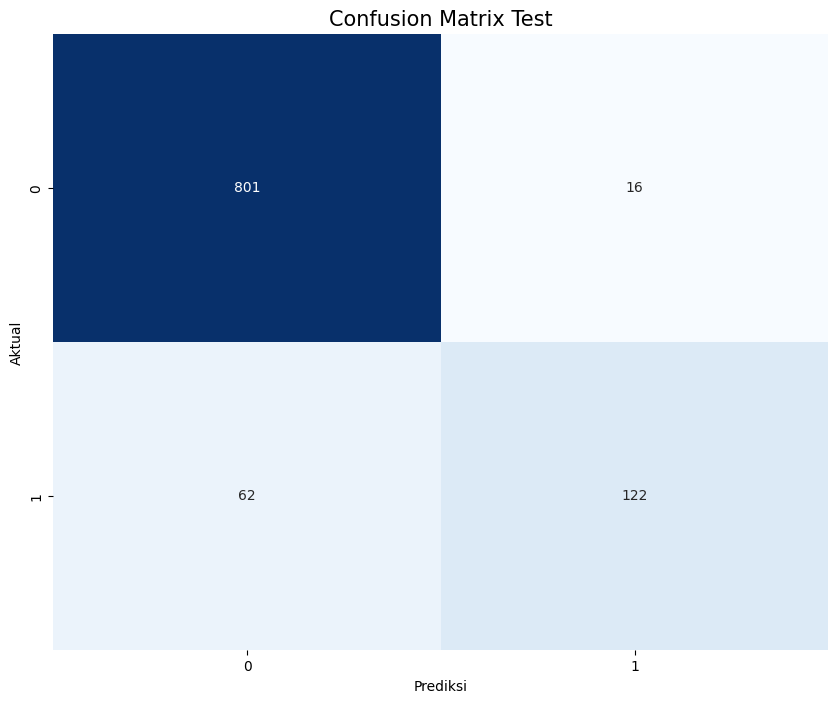

In [252]:
cmtrx(y_train, y_pred_train)
cmtrx(y_test, y_pred_test, title='Test')

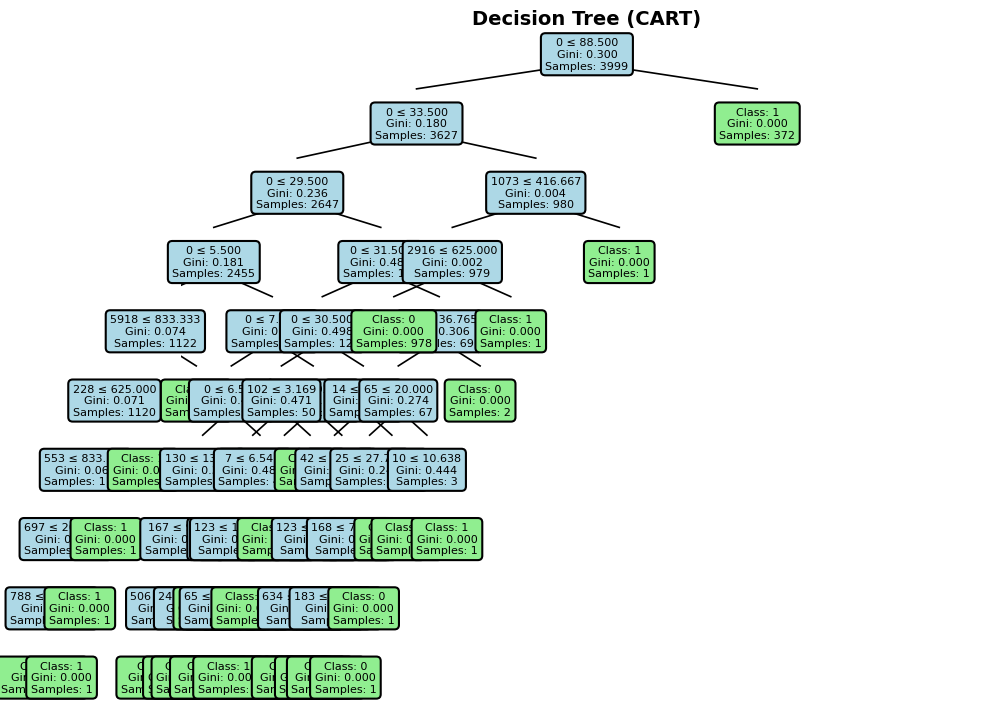

In [ ]:
feature_name = pd.DataFrame(X)

def visualize_tree(node, feature_names, depth=0, x=0.5, y=1.0, dx=0.25, parent_x=None, parent_y=None):
    if node is None:
        return
    
    is_leaf = node.left is None and node.right is None
    
    box_props = dict(
        boxstyle='round,pad=0.4',
        facecolor='lightgreen' if is_leaf else 'lightblue',
        edgecolor='black',
        linewidth=1.5
    )
    
    if is_leaf:
        label = f'Class: {node.pred_class}\nGini: {node.gini:.3f}\nSamples: {node.num_samples}'
    else:
        feature_name = feature_names[node.feature] if node.feature < len(feature_names) else f'Feature[{node.feature}]'
        label = f'{feature_name} ≤ {node.threshold:.3f}\nGini: {node.gini:.3f}\nSamples: {node.num_samples}'
    
    plt.text(x, y, label, ha='center', va='center', fontsize=8, 
             bbox=box_props, zorder=3, wrap=True)
    
    if parent_x is not None and parent_y is not None:
        plt.plot([parent_x, x], [parent_y - 0.02, y + 0.08], 'k-', linewidth=1.2, zorder=1)
    
    if is_leaf:
        return
    
    next_y = y - 0.16
    next_dx = dx * 0.7 
    
    left_x = x - next_dx
    right_x = x + next_dx
    
    visualize_tree(node.left, feature_names, depth + 1, left_x, next_y, next_dx, x, y)
    visualize_tree(node.right, feature_names, depth + 1, right_x, next_y, next_dx, x, y)

plt.figure(figsize=(10, 8))
visualize_tree(model.root, feature_name.columns.to_list(), dx=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.axis('off')
plt.title('Decision Tree (CART)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. GUI 

In [265]:
def predict_dari_gui():
    judul_input = entry_judul.get() 
    
    if not judul_input.strip():
        messagebox.showwarning("Peringatan", "Masukkan judul produk terlebih dahulu!")
        return

    judul_bersih = nltk_cleaner(judul_input)
    
    skor_tf = hitung_tf(judul_bersih)
    vector_input = np.zeros(len(X_tfidf.columns.to_list()))
    
    for i, kata in enumerate(X_tfidf.columns.to_list()):
        if kata in skor_tf:
            # TF * IDF
            vector_input[i] = skor_tf[kata] * skor_idf.get(kata, 0)
    prediksi_id = model.predict([vector_input])[0]
    
    nama_kategori = id_to_category.get(prediksi_id, "Tidak Diketahui")
    
    label_hasil.config(text=f"Kategori: {nama_kategori}", fg="blue")
    messagebox.showinfo("Hasil Prediksi", f"Produk ini masuk kategori:\n{nama_kategori}")

root = tk.Tk()
root.title("LProduct Classifier")
root.geometry("400x300")

tk.Label(root, text="Masukkan Judul Produk:").pack(pady=10)
entry_judul = tk.Entry(root, width=50)
entry_judul.pack(pady=5)

btn_predict = tk.Button(root, text="Klasifikasi Produk", command=predict_dari_gui)
btn_predict.pack(pady=20)

label_hasil = tk.Label(root, text="Kategori: -", font=("Arial", 12, "bold"))
label_hasil.pack(pady=10)

root.mainloop()

In [264]:
product.sample(5)

,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label,title_word_count,Clean_Title,target
10601,intel core i5 3450s 2.8ghz 65w quad core socke...,121,6996,Intel Core i5-3450S 2.8GHz Box,2615,CPUs,24,intel core i5 3450s 28ghz 65w quad core socket...,2
12991,sony alpha 7s geh use,253,39017,Sony Alpha 7S,2617,Digital Cameras,5,sony alpha 7s geh use,3
20687,hotpoint wmbf742p 7kg 1400rpm freestanding was...,3,41930,Hotpoint WMBF742P,2620,Washing Machines,8,hotpoint wmbf742p 7kg 1400rpm freestanding was...,6
14696,mikrowellenger t hmt 75m451,40,39708,Bosch HMT75M451 Stainless Steel,2618,Microwaves,4,mikrowellenger hmt 75m451,4
23176,hoover dynamic next free standing washing mach...,31,42521,Hoover DXOA69HC3B,2620,Washing Machines,9,hoover dynamic next standing washing machine b...,6


## 8. Conclution

- dfataset cukup bersih, dimana dataset tidak memiliki nilai kosong dan duplikat
- 